In [1]:
import json
import torch
import numpy as np
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from transformers import EarlyStoppingCallback
from torch.utils.data import Dataset
from google.colab import drive
import os


drive.mount('/content/drive')

save_path = '/content/drive/MyDrive/Bankacilik/'
os.makedirs(save_path, exist_ok=True)


print(" Veri seti yükleniyor...")
with open(os.path.join(save_path, 'banking_dataset_genisletilmis_80_tr_duzeltilmis.json'), 'r', encoding='utf-8') as f:
    veri_liste = json.load(f)


veri_sozluk = {}
for item in veri_liste:
    kat = item['label']
    text = item['text']
    if kat not in veri_sozluk:
        veri_sozluk[kat] = []
    veri_sozluk[kat].append(text)

print(f" {len(veri_liste)} cümle, {len(veri_sozluk)} kategori")


kategoriler = list(veri_sozluk.keys())
kategori_to_id = {kat: idx for idx, kat in enumerate(kategoriler)}
id_to_kategori = {idx: kat for kat, idx in kategori_to_id.items()}

print("\n KATEGORİ HARİTASI:")
for kat, idx in kategori_to_id.items():
    print(f"   {idx}: {kat}")





Mounted at /content/drive
 Veri seti yükleniyor...
 1280 cümle, 16 kategori

 KATEGORİ HARİTASI:
   0: kart_aktivasyon
   1: kart_iptal
   2: ucret_ve_komisyonlar
   3: kart_basvuru
   4: kart_faiz
   5: havale_iban
   6: sifre_unuttum
   7: sube_atm
   8: dolandiricilik
   9: musteri_hizmetleri
   10: ihtiyac_kredisi_basvuru
   11: ihtiyac_kredisi_faiz
   12: konut_kredisi_basvuru
   13: konut_kredisi_faiz
   14: tasit_kredisi_basvuru
   15: tasit_kredisi_faiz


In [2]:
labels = []
texts = []

for item in veri_liste:
    texts.append(item['text'])
    labels.append(kategori_to_id[item['label']])

# %80 eğitim, %20 test
train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"\n VERİ BÖLÜNMESİ:")
print(f"   • Eğitim: {len(train_texts)} cümle")
print(f"   • Test: {len(test_texts)} cümle")


model_adi = "dbmdz/bert-base-turkish-128k-cased"
tokenizer = AutoTokenizer.from_pretrained(model_adi)


class IntentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }


train_dataset = IntentDataset(train_texts, train_labels, tokenizer)
test_dataset = IntentDataset(test_texts, test_labels, tokenizer)


print("\n BERT modeli yükleniyor")
model = AutoModelForSequenceClassification.from_pretrained(
    model_adi,
    num_labels=len(kategoriler)
)


 VERİ BÖLÜNMESİ:
   • Eğitim: 1024 cümle
   • Test: 256 cümle


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/386 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]


 BERT modeli yükleniyor


model.safetensors:   0%|          | 0.00/740M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dbmdz/bert-base-turkish-128k-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [3]:
training_args = TrainingArguments(
    output_dir=os.path.join(save_path, 'bert_intent_model'),
    num_train_epochs=10,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir=os.path.join(save_path, 'logs'),
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    fp16=True,
    report_to="none"
)


def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    accuracy = np.mean(predictions == labels)
    return {"accuracy": accuracy}


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)


print("\n BERT fine-tuning başlıyor")
trainer.train()

model_save_path = os.path.join(save_path, 'bert_intent_model_final')
trainer.save_model(model_save_path)
tokenizer.save_pretrained(model_save_path)

print(f"\n Model kaydedildi: {model_save_path}")


results = trainer.evaluate()
print(f"\n TEST SONUÇLARI:")
print(f"   • Accuracy: {results['eval_accuracy']:.4f}")
print(f"   • Loss: {results['eval_loss']:.4f}")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.



 BERT fine-tuning başlıyor


Epoch,Training Loss,Validation Loss,Accuracy
1,2.545819,2.148151,0.335938
2,0.525987,0.222174,0.945312
3,0.180354,0.172313,0.937500
4,0.111748,0.189891,0.957031
5,0.070199,0.234222,0.957031
6,0.034923,0.231036,0.953125
7,0.120903,0.235555,0.945312


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


 Model kaydedildi: /content/drive/MyDrive/Bankacilik/bert_intent_model_final



 TEST SONUÇLARI:
   • Accuracy: 0.9570
   • Loss: 0.1898



 SINIFLANDIRMA RAPORU:
                         precision    recall  f1-score   support

        kart_aktivasyon       1.00      1.00      1.00        16
             kart_iptal       1.00      0.88      0.93        16
   ucret_ve_komisyonlar       1.00      1.00      1.00        16
           kart_basvuru       0.94      1.00      0.97        16
              kart_faiz       1.00      0.94      0.97        16
            havale_iban       1.00      1.00      1.00        16
          sifre_unuttum       1.00      0.94      0.97        16
               sube_atm       1.00      1.00      1.00        16
         dolandiricilik       0.84      1.00      0.91        16
     musteri_hizmetleri       1.00      1.00      1.00        16
ihtiyac_kredisi_basvuru       1.00      0.94      0.97        16
   ihtiyac_kredisi_faiz       0.79      0.94      0.86        16
  konut_kredisi_basvuru       0.94      1.00      0.97        16
     konut_kredisi_faiz       0.92      0.75      0.83        16


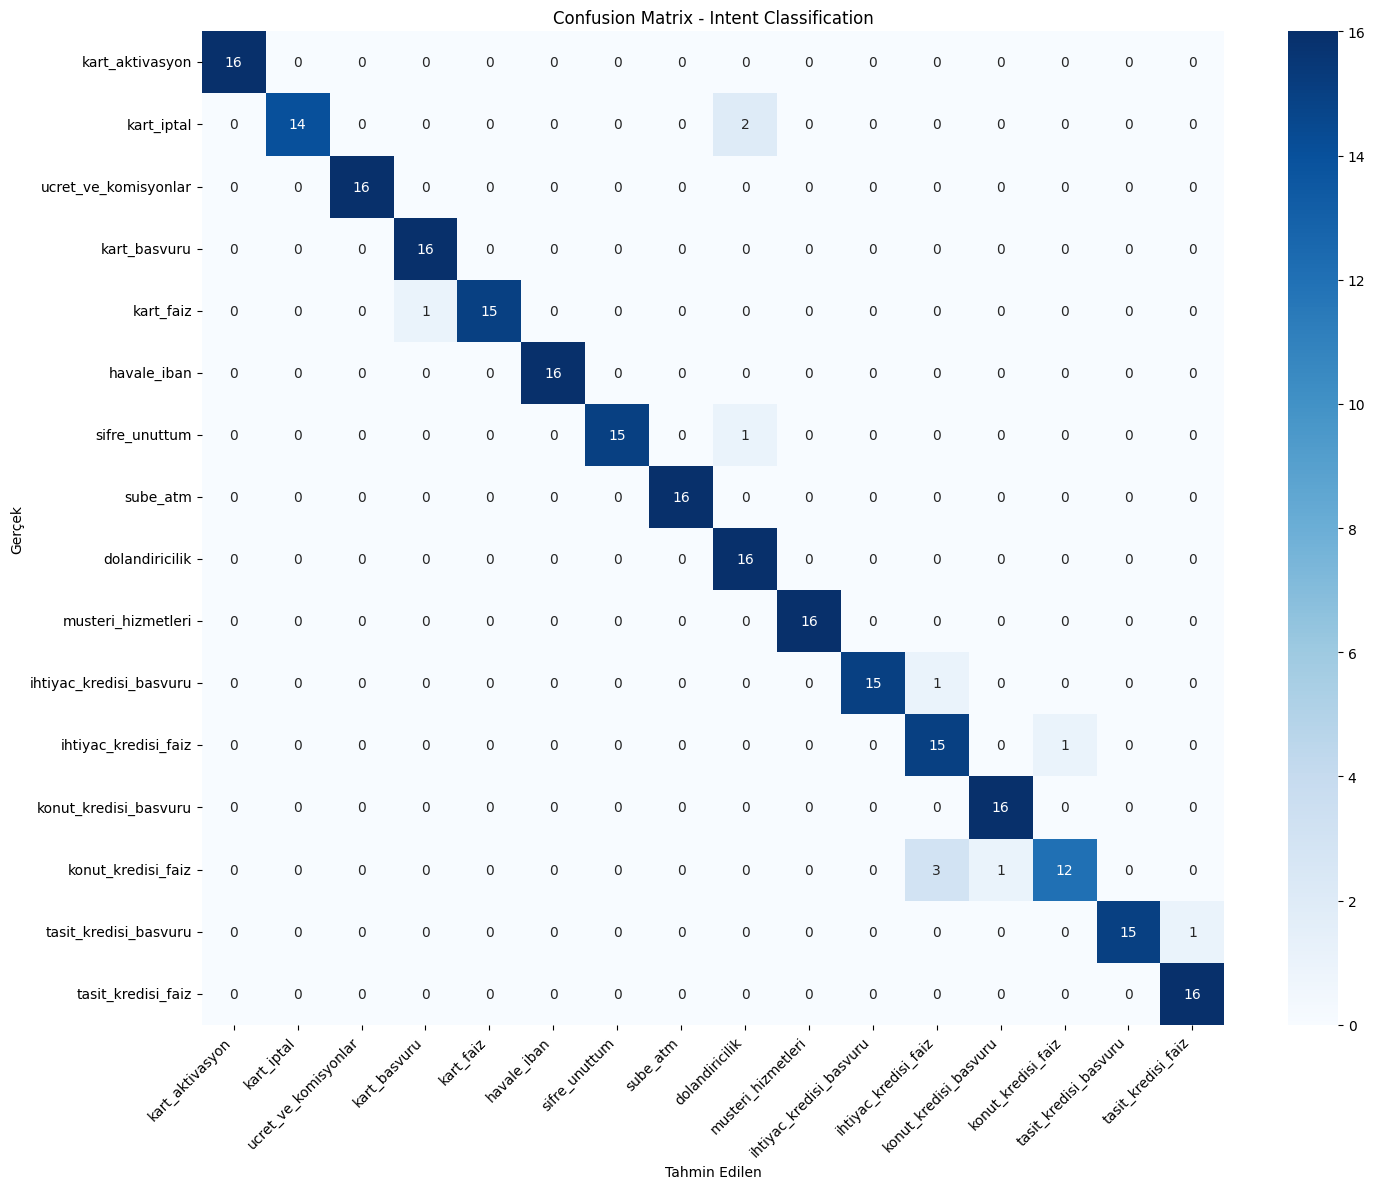


 INTENT DETECTION TEST:


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


 Kredi kartımı nasıl aktif edebilirim?
   ➡️ Kategori: kart_aktivasyon (Güven: 89.70%)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


 Kartım çalındı hemen bloke edin
   ➡️ Kategori: kart_iptal (Güven: 98.27%)


...


 İhtiyaç kredisi faiz oranları nedir?
   ➡️ Kategori: ihtiyac_kredisi_faiz (Güven: 99.36%)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


 En yakın ATM nerede?
   ➡️ Kategori: sube_atm (Güven: 99.56%)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


 Şifremi unuttum ne yapmalıyım?
   ➡️ Kategori: sifre_unuttum (Güven: 94.75%)

 GÜVEN SKORU EŞİKLERİ

YÜKSEK GÜVEN (> 0.80): RAG sistemine yönlendir
ORTA GÜVEN (0.50-0.80): Onay sor ("X ile mi ilgili?")
DÜŞÜK GÜVEN (< 0.50): Açıklama iste ("Anlayamadım, detaylandırın")


 Kategori haritası kaydedildi

 ADIM 1 TAMAMLANDI!

📁 DRIVE'DAKİ DOSYALAR:
1. bert_intent_model_final/ - Fine-tune edilmiş BERT modeli
2. kategori_haritasi_final.json - Kategori ID eşleştirmeleri
3. confusion_matrix.png - Performans görseli

📊 MODEL PERFORMANSI:
• Accuracy: 0.9570
• Toplam kategori: 16
• Test seti: 256 cümle

🎯 SONRAKİ ADIM: RAG Sistemi Kurulumu
• ChromaDB ile vektör veritabanı oluştur
• Embedding modeli ekle
• Bilgi bankasını indexle



In [4]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

print("\n SINIFLANDIRMA RAPORU:")
print("="*50)
print(classification_report(y_true, y_pred, target_names=kategoriler))

# Confusion Matrix
plt.figure(figsize=(15, 12))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=kategoriler, yticklabels=kategoriler)
plt.title('Confusion Matrix - Intent Classification')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(save_path, 'confusion_matrix.png'))
plt.show()

from transformers import pipeline

def detect_intent(text, model_path=model_save_path, id_to_kat=id_to_kategori):
    """Verilen metnin niyetini tahmin eder"""
    classifier = pipeline("text-classification", model=model_path, tokenizer=model_path)
    result = classifier(text)[0]

    label_id = int(result['label'].split('_')[-1])
    kategori = id_to_kat[label_id]
    confidence = result['score']

    return kategori, confidence

# Test
print("\n INTENT DETECTION TEST:")
print("="*50)
test_sentences = [
    "Kredi kartımı nasıl aktif edebilirim?",
    "Kartım çalındı hemen bloke edin",
    "İhtiyaç kredisi faiz oranları nedir?",
    "En yakın ATM nerede?",
    "Şifremi unuttum ne yapmalıyım?"
]

for sentence in test_sentences:
    kat, conf = detect_intent(sentence)
    print(f"\n {sentence}")
    print(f"   ➡️ Kategori: {kat} (Güven: {conf:.2%})")


print("\n" + "="*50)
print(" GÜVEN SKORU EŞİKLERİ")
print("="*50)
print("""
YÜKSEK GÜVEN (> 0.80): RAG sistemine yönlendir
ORTA GÜVEN (0.50-0.80): Onay sor ("X ile mi ilgili?")
DÜŞÜK GÜVEN (< 0.50): Açıklama iste ("Anlayamadım, detaylandırın")
""")


with open(os.path.join(save_path, 'kategori_haritasi_final.json'), 'w', encoding='utf-8') as f:
    json.dump({
        "kategori_to_id": kategori_to_id,
        "id_to_kategori": id_to_kategori
    }, f, ensure_ascii=False, indent=2)

print(f"\n Kategori haritası kaydedildi")


print("\n" + "="*50)
print(" ADIM 1 TAMAMLANDI!")
print("="*50)
print(f"""
📁 DRIVE'DAKİ DOSYALAR:
1. bert_intent_model_final/ - Fine-tune edilmiş BERT modeli
2. kategori_haritasi_final.json - Kategori ID eşleştirmeleri
3. confusion_matrix.png - Performans görseli

📊 MODEL PERFORMANSI:
• Accuracy: {results['eval_accuracy']:.4f}
• Toplam kategori: {len(kategoriler)}
• Test seti: {len(test_texts)} cümle

🎯 SONRAKİ ADIM: RAG Sistemi Kurulumu
• ChromaDB ile vektör veritabanı oluştur
• Embedding modeli ekle
• Bilgi bankasını indexle
""")